# PCA Trajectory of PGD Attacks in the Keyword Spotter's Embedding Space

The audio counterpart of `latent_space/PCA_trajectory.ipynb` in the vision repo and
`latent_space/embedding_trajectory.ipynb` in the NLP repo: extract the penultimate-layer feature
vector (the 64-dimensional output of `global_pool`, right before the final linear classifier),
fit PCA on a background cloud of ordinary clips to get a stable 2D reference frame, then trace
where a clip's embedding moves as PGD perturbs it more and more.


In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import soundfile as sf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

torch.manual_seed(0)

def _load_wav(path, frame_offset=0, num_frames=-1, normalize=True, channels_first=True, format=None, buffer_size=4096, backend=None):
    """Replaces torchaudio's TorchCodec-based loader (needs a separately installed FFmpeg, not
    available here) with soundfile, which reads WAV directly with no extra system dependencies."""
    data, sample_rate = sf.read(path, dtype='float32')
    waveform = torch.from_numpy(data)
    if waveform.dim() == 1:
        waveform = waveform.unsqueeze(1)
    if channels_first:
        waveform = waveform.transpose(0, 1)
    return waveform, sample_rate

torchaudio.load = _load_wav

### Setup: Model and Embeddings
The trained `KeywordCNN` exposes its penultimate features naturally, `global_pool(conv3(...))`
flattened to 64 dimensions, right before `fc`. `embed()` below runs the same forward pass but
returns that intermediate tensor instead of the final logits.

In [2]:
LABELS = ['yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go']
LABEL_TO_IDX = {label: i for i, label in enumerate(LABELS)}
SAMPLE_RATE = 16000

mel_spectrogram = torchaudio.transforms.MelSpectrogram(sample_rate=SAMPLE_RATE, n_mels=64, n_fft=400, hop_length=160)
to_db = torchaudio.transforms.AmplitudeToDB()

def waveform_to_spectrogram(waveform):
    return to_db(mel_spectrogram(waveform))

class KeywordCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(64, num_classes)

    def forward(self, spectrogram):
        x = self.pool(F.relu(self.bn1(self.conv1(spectrogram))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = F.relu(self.bn3(self.conv3(x)))
        return self.global_pool(x).flatten(1)

    def classify(self, features):
        return self.fc(features)

model = KeywordCNN(num_classes=len(LABELS))
model.load_state_dict(torch.load('../models/keyword_spotter.pth', map_location='cpu'))
model.eval()

@torch.no_grad()
def embed(waveform):
    return model(waveform_to_spectrogram(waveform.unsqueeze(0)))[0].numpy()

@torch.no_grad()
def predict_from_waveform(waveform):
    features = model(waveform_to_spectrogram(waveform.unsqueeze(0)))
    return int(torch.argmax(model.classify(features), dim=-1))

### Background Cloud
Embed a broad sample of real test clips and fit PCA on them, the stable 2D reference frame the
PGD trajectories below get projected into.

In [3]:
os.makedirs('../models/speech_commands_data', exist_ok=True)
test_data = torchaudio.datasets.SPEECHCOMMANDS(root='../models/speech_commands_data', download=True, subset='testing')

def pad_or_trim(waveform):
    if waveform.shape[1] < SAMPLE_RATE:
        return F.pad(waveform, (0, SAMPLE_RATE - waveform.shape[1]))
    return waveform[:, :SAMPLE_RATE]

N_PER_CLASS = 15
counts = {label: 0 for label in LABELS}
background_clips, background_labels = [], []
for i in range(len(test_data)):
    _, _, label, *_ = test_data.get_metadata(i)
    if label not in LABEL_TO_IDX or counts[label] >= N_PER_CLASS:
        continue
    counts[label] += 1
    waveform, sr, label, *_ = test_data[i]
    background_clips.append(pad_or_trim(waveform))
    background_labels.append(LABEL_TO_IDX[label])

background_embeddings = np.stack([embed(w) for w in background_clips])
pca = PCA(n_components=2)
background_2d = pca.fit_transform(background_embeddings)
print(f"Background: {len(background_clips)} clips. Explained variance: PC1 {pca.explained_variance_ratio_[0]*100:.1f}%, PC2 {pca.explained_variance_ratio_[1]*100:.1f}%")

Background: 150 clips. Explained variance: PC1 33.7%, PC2 30.3%


### PGD Trajectories
For 3 example clips (one held-out clip per class, reusing the first 3 classes), embed the clip
after every single PGD step, so the intermediate points along the trajectory are visible, not
just the final result.

In [4]:
def pgd_trajectory(waveform, true_label_idx, epsilon, iters=10):
    alpha = epsilon / (iters / 2.0)
    adv = waveform.clone()
    trajectory = [waveform]
    for _ in range(iters):
        adv = adv.clone().requires_grad_(True)
        features = model(waveform_to_spectrogram(adv.unsqueeze(0)))
        loss = F.cross_entropy(model.classify(features), torch.tensor([true_label_idx]))
        loss.backward()
        adv = adv + alpha * adv.grad.sign()
        perturbation = torch.clamp(adv - waveform, -epsilon, epsilon)
        adv = torch.clamp(waveform + perturbation, -1.0, 1.0).detach()
        trajectory.append(adv)
    return trajectory

EPSILON = 0.05
example_labels = LABELS[:3]
trajectories = {}
for label in example_labels:
    idx = background_labels.index(LABEL_TO_IDX[label])
    waveform = background_clips[idx]
    steps = pgd_trajectory(waveform, LABEL_TO_IDX[label], EPSILON)
    embeddings_2d = pca.transform(np.stack([embed(w) for w in steps]))
    trajectories[label] = embeddings_2d
    final_pred = LABELS[predict_from_waveform(steps[-1])]
    print(f"{label} -> {final_pred} after 10 PGD steps ($\\varepsilon={EPSILON}$)")

yes -> on after 10 PGD steps ($\varepsilon=0.05$)
no -> off after 10 PGD steps ($\varepsilon=0.05$)


up -> no after 10 PGD steps ($\varepsilon=0.05$)


### Plot: Background Regions and PGD Trajectories

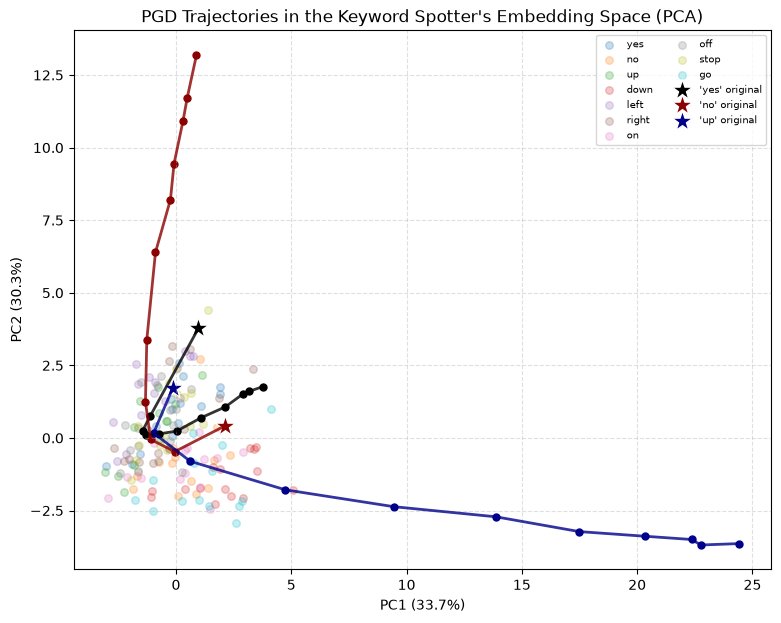

In [5]:
plt.figure(figsize=(9, 7))

cmap = plt.get_cmap('tab10')
for class_idx in range(len(LABELS)):
    mask = [l == class_idx for l in background_labels]
    points = background_2d[mask]
    plt.scatter(points[:, 0], points[:, 1], color=cmap(class_idx), alpha=0.25, s=30,
                label=LABELS[class_idx])

trajectory_colors = ['black', 'darkred', 'darkblue']
for (label, points), color in zip(trajectories.items(), trajectory_colors):
    plt.plot(points[:, 0], points[:, 1], '-', color=color, linewidth=2, alpha=0.8)
    plt.scatter(points[1:, 0], points[1:, 1], c=color, s=25)
    plt.scatter(points[0, 0], points[0, 1], c=color, marker='*', s=250, edgecolors='white',
                label=f"'{label}' original")

plt.title('PGD Trajectories in the Keyword Spotter\'s Embedding Space (PCA)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(fontsize=7, loc='best', ncol=2)
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()